In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

In [3]:
sample_rate = 16000
duration = 2.0

N = int(sample_rate * duration)
time = np.arange(N)/sample_rate #0 to 2 sec

signal = np.zeros(N)

#1st second
signal[:sample_rate] = np.sin(
    2 * np.pi * 300 * time[:sample_rate]
)
#2nd second
signal[sample_rate:] = np.sin(
    2 * np.pi * 700 * time[sample_rate:]
)

In [4]:
stft_result = librosa.stft(
    signal,
    n_fft=2048,
    hop_length=512,
    win_length=2048,
    window="hann"
)

In [5]:
#power spectrum
power_spectrum = np.abs(stft_result)**2

#mel filters
mel_filters = librosa.filters.mel(
    sr=sample_rate,
    n_fft=2048,
    n_mels=80,
    fmin=0,
    fmax=8000
)

In [6]:
mel_spectrogram = (
    mel_filters @ power_spectrum
)

In [7]:
print(mel_spectrogram.shape)

(80, 63)


In [8]:
#inbuilt method
mel_spectrogram = librosa.feature.melspectrogram(
    y=signal,
    sr=sample_rate,
    n_fft=2048,
    hop_length=512,
    win_length=2048,
    n_mels=80,
    fmin=0,
    fmax=8000,
    power=2.0
)

#power = 2.0 means use |stft|^2

In [9]:
print(mel_spectrogram.shape)

(80, 63)


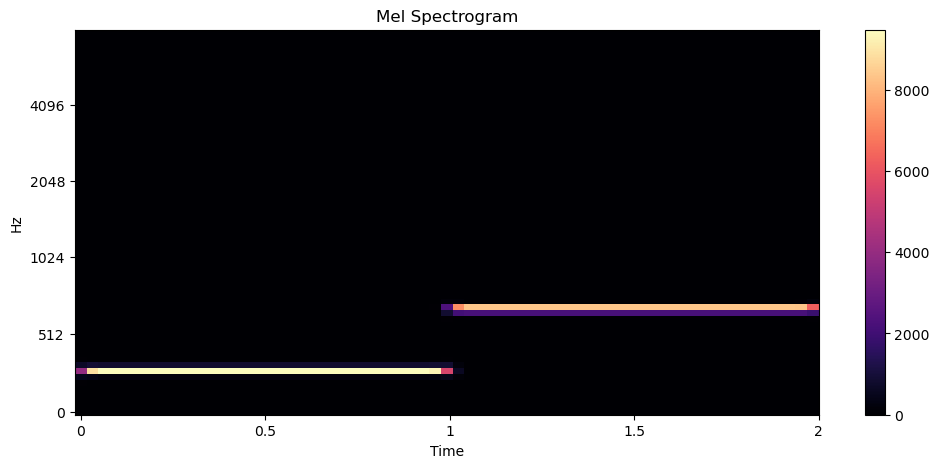

In [10]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_spectrogram,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()
plt.title("Mel Spectrogram")

plt.show()